In [60]:

!pip install yfinance -q

import yfinance as yf
import pandas as pd

# SK하이닉스 KRX 티커: 000660.KS
ticker = "000660.KS"

""" 
주식 거래의 법칙 중, 거래량이 동반 된 상승은 이후에 큰 상승이 있을것이고, 거래량이 동반 된 하락은 이후에 큰 하락이 있을 것이라 한다.
2020년과 2025년기준으로 상승 및 하락 거래량 Top5 기준으로 5거래일 간 평균 가격 변화량을 측정한다."""


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\YW\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


' \n주식 거래의 법칙 중, 거래량이 동반 된 상승은 이후에 큰 상승이 있을것이고, 거래량이 동반 된 하락은 이후에 큰 하락이 있을 것이라 한다.\n2020년과 2025년기준으로 상승 및 하락 거래량 Top5 기준으로 5거래일 간 평균 가격 변화량을 측정한다.'

In [61]:
print("문제 1 : 2020년과 2025년의 제공되는 SK하이닉스 주식 전체 정보를 출력")

df_2020 = yf.download(ticker, start="2020-01-01", end="2020-12-31", auto_adjust=True)  
print(df_2020)
print(df_2020.shape)

df_2025 = yf.download(ticker, start="2025-01-01", end="2025-12-31", auto_adjust=True)
print(df_2025)
print(df_2025.shape)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

문제 1 : 2020년과 2025년의 제공되는 SK하이닉스 주식 전체 정보를 출력
Price               Close           High            Low           Open  \
Ticker          000660.KS      000660.KS      000660.KS      000660.KS   
Date                                                                     
2020-01-02   88883.953125   90291.829890   88320.802419   90104.112988   
2020-01-03   88696.250000   91887.437831   88508.533069   90573.419312   
2020-01-06   88508.531250   89447.115887   87100.654295   87288.371222   
2020-01-07   88226.953125   89540.971576   88226.953125   88696.245429   
2020-01-08   91418.148438   93389.176279   89353.262128   90479.563751   
...                   ...            ...            ...            ...   
2020-12-23  108875.812500  108875.812500  105590.766433  106060.058728   
2020-12-24  110752.992188  111222.284527  108406.530489  108875.822828   
2020-12-28  108406.523438  112160.861912  107937.231128  111691.569602   
2020-12-29  109989.984375  112360.458176  108093.605334  111886.36

In [69]:
print("문제2 : 해당 주식에서 값이 포함되어 있지 않은 결측데이터는 삭제하여 기존 행렬에 저장")
print("2020 결측치:\n", df_2020.isnull())
print("2025 결측치:\n", df_2025.isnull())

df_2020 = df_2020.dropna()
df_2025 = df_2025.dropna()

print("2020:", df_2020.shape) #결측치 제거후 shape작업
print("2025:", df_2025.shape)



문제2 : 해당 주식에서 값이 포함되어 있지 않은 결측데이터는 삭제하여 기존 행렬에 저장
2020 결측치:
 Price       Close   High    Low   Open  Volume     방향
Date                                                 
2020-01-02  False  False  False  False   False  False
2020-01-03  False  False  False  False   False  False
2020-01-06  False  False  False  False   False  False
2020-01-07  False  False  False  False   False  False
2020-01-08  False  False  False  False   False  False
...           ...    ...    ...    ...     ...    ...
2020-12-23  False  False  False  False   False  False
2020-12-24  False  False  False  False   False  False
2020-12-28  False  False  False  False   False  False
2020-12-29  False  False  False  False   False  False
2020-12-30  False  False  False  False   False  False

[248 rows x 6 columns]
2025 결측치:
 Price       Close   High    Low   Open  Volume     방향
Date                                                 
2025-01-02  False  False  False  False   False  False
2025-01-03  False  False  False  False  

In [73]:
print("문제3 : 각 년도의 일자별 상승 및 하락을 정리하고, 상승과 하락의 Top 5 거래량을 추출.")

print("상승 및 하락 계산")
df_2020['방향'] = (df_2020['Close'] - df_2020['Open']).apply(lambda x: '상승' if x > 0 else '하락')
df_2025['방향'] = (df_2025['Close'] - df_2025['Open']).apply(lambda x: '상승' if x > 0 else '하락')


print(df_2020.sort_values('Volume', ascending=False).head(5))
print(df_2025.sort_values('Volume', ascending=False).head(5))

print("상승 및 하락 Top5의 거래량 Sorting")
for year, df in [("2020", df_2020), ("2025", df_2025)]:
    for 방향 in ['상승', '하락']:
        filtered = df[df['방향'] == 방향].sort_values('Volume', ascending=False).head(5).copy()
        filtered['Close'] = filtered['Close'].astype(int)
        filtered['등락량'] = (filtered['Close'] - filtered['Open']).astype(int)
        filtered['등락률(%)'] = ((filtered['Close'] - filtered['Open']) / filtered['Open'] * 100).round(2)
        print(f"\n{year} {방향}일 거래량 Top5:")
        print(filtered[['Close', 'Volume', '방향', '등락량', '등락률(%)']])



문제3 : 각 년도의 일자별 상승 및 하락을 정리하고, 상승과 하락의 Top 5 거래량을 추출.
상승 및 하락 계산
Price              Close          High           Low          Open    Volume  \
Date                                                                           
2020-06-03  83252.453125  83721.745420  78277.954798  78277.954798  11642239   
2020-03-19  64762.351562  71144.728238  61758.880186  70863.152797  11140367   
2020-11-16  91981.304688  92075.163162  85505.069970  86443.654711   9274278   
2020-05-28  78747.265625  80155.142841  77339.388409  78934.982587   9227823   
2020-03-25  79310.414062  79498.131019  74899.065588  76963.952108   8787217   

Price       방향  
Date            
2020-06-03  상승  
2020-03-19  하락  
2020-11-16  상승  
2020-05-28  하락  
2020-03-25  상승  
Price              Close           High            Low           Open  \
Date                                                                    
2025-01-31  196741.43750  201976.023940  192395.743097  194568.590299   
2025-07-17  268378.50000  288295.271

In [74]:
print("문제4 : 두 년도의 상승/하락 별 Top5 거래량의 다음날 주가가 어떻게 되었는지 정리.")

for year, df in [("2020", df_2020), ("2025", df_2025)]:
    for 방향 in ['상승', '하락']:
        filtered = df[df['방향'] == 방향].sort_values('Volume', ascending=False).head(5).copy()
        
        # 당일 등락량/등락률
        filtered['등락량'] = (filtered['Close'] - filtered['Open']).astype(int)
        filtered['등락률(%)'] = ((filtered['Close'] - filtered['Open']) / filtered['Open'] * 100).round(2)
        
        # 다음날 종가
        df_next = df['Close'].shift(-1)
        filtered['다음날종가'] = df_next[filtered.index].values
        
        filtered['Close'] = filtered['Close'].astype(int)
        filtered['다음날종가'] = filtered['다음날종가'].astype(float).round(0).astype(int)
        filtered['다음날등락량'] = filtered['다음날종가'] - filtered['Close']
        filtered['다음날등락률(%)'] = ((filtered['다음날종가'] - filtered['Close']) / filtered['Close'] * 100).round(2)
        
        print(f"\n{year} {방향}일 거래량 Top5 → 다음날 변화:")
        print(filtered[['Close', 'Volume', '등락량', '등락률(%)', '다음날종가', '다음날등락량', '다음날등락률(%)']])

문제4 : 두 년도의 상승/하락 별 Top5 거래량의 다음날 주가가 어떻게 되었는지 정리.

2020 상승일 거래량 Top5 → 다음날 변화:
Price       Close    Volume   등락량  등락률(%)  다음날종가  다음날등락량  다음날등락률(%)
Date                                                               
2020-06-03  83252  11642239  4974    6.35  82314    -938      -1.13
2020-11-16  91981   9274278  5537    6.41  92075      94       0.10
2020-03-25  79310   8787217  2346    3.05  75744   -3566      -4.50
2020-03-20  70206   8750101  2815    4.18  65138   -5068      -7.22
2020-03-13  77433   8160758  5256    7.28  75650   -1783      -2.30

2020 하락일 거래량 Top5 → 다음날 변화:
Price        Close    Volume   등락량  등락률(%)   다음날종가  다음날등락량  다음날등락률(%)
Date                                                                 
2020-03-19   64762  11140367 -6100   -8.61   70206    5444       8.41
2020-05-28   78747   9227823  -187   -0.24   76495   -2252      -2.86
2020-12-04  107937   8258814  -938   -0.86  110753    2816       2.61
2020-12-10  109345   8205744  -469   -0.43  108407    -938      -

문제5 : 연도별/방향별 Top5거래량의 다음날 변동폭을 시각화하라.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\YW\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


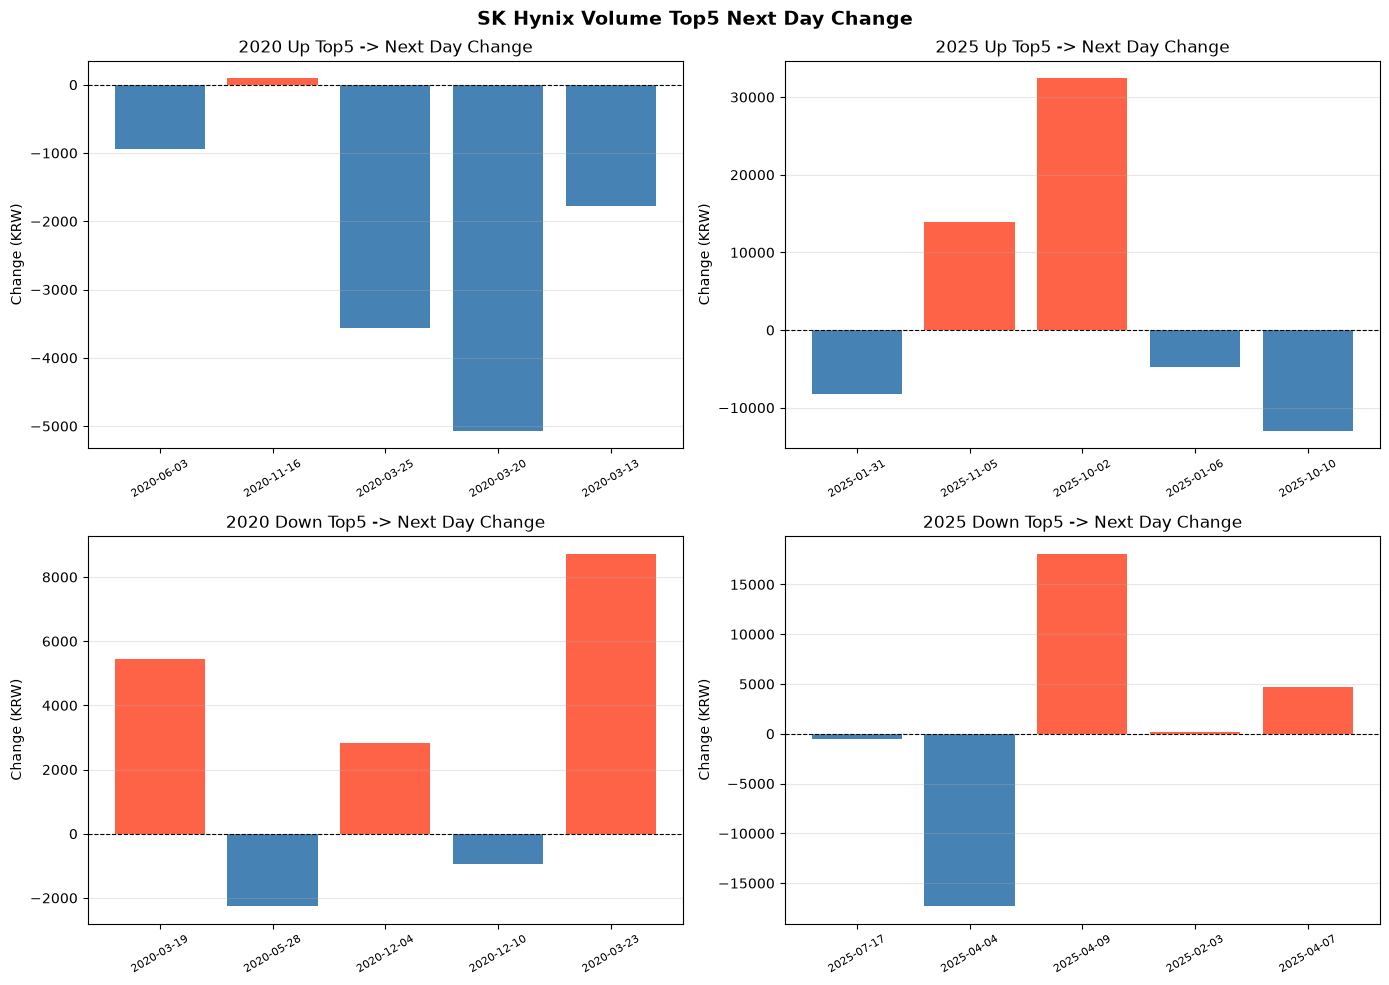

'\n결과에 대한 분석 : 거래량이 동반한 하락/상승 장에서 연관성은 크게 없는것으로 이해됐다.\n2020년에 거래량을 동반한 상승 이후에 다음날 하락은 4일이었고, 2025년에는 상승이 2일 하락이 3일로 전체로 따져봤을 때 오히려 하락이 더 많았다.\n2020년에 거래량을 동반한 하락 이후에 다음날 상승은 3일이었고, 2025년에는 상승이 3일 하락이 2일로 전체로 따져봤을 때 비슷한 수치였다.\n거래량 동반 상승 이후에 하락의 폭이 큰 날이 많았고, 거래량 동반 하락 이후에 상승의 폭이 큰 날이 비교적 많았다.\n워랜버핏의 명언중에 공포에 매수해라 라는 말이 있듯이 매수할 타이밍을 잡고있다면, 거래량을 크게 동반한 하락에 매수를 한다면 다음날 대규모 상승을 할 확률이 조금이라도 올라 갈 것같다.\n물론 더 많은 데이터 비교가 필요하고 당시 시장의 상황도 고려해야하지만....'

In [76]:
print("문제5 : 연도별/방향별 Top5거래량의 다음날 변동폭을 시각화하하고 결과를 해석")

!pip install matplotlib -q

import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("SK Hynix Volume Top5 Next Day Change", fontsize=14, fontweight='bold')

for col, (year, df) in enumerate([("2020", df_2020), ("2025", df_2025)]):
    for row, direction in enumerate(['상승', '하락']):
        filtered = df[df['방향'] == direction].sort_values('Volume', ascending=False).head(5).copy()
        df_next = df['Close'].shift(-1)
        filtered['다음날종가'] = df_next[filtered.index].values
        filtered['다음날등락량'] = (filtered['다음날종가'] - filtered['Close']).astype(int)
        
        labels = [str(d.date()) for d in filtered.index]
        bar_colors = ['tomato' if v > 0 else 'steelblue' for v in filtered['다음날등락량']]
        label_kr = 'Up' if direction == '상승' else 'Down'
        
        axes[row, col].bar(labels, filtered['다음날등락량'], color=bar_colors)
        axes[row, col].axhline(0, color='black', linewidth=0.8, linestyle='--')
        axes[row, col].set_title(f"{year} {label_kr} Top5 -> Next Day Change")
        axes[row, col].set_ylabel("Change (KRW)")
        axes[row, col].tick_params(axis='x', rotation=30, labelsize=8)
        axes[row, col].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("hynix_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

"""
결과에 대한 해석 : 거래량이 동반한 하락/상승 장에서 연관성은 크게 없는것으로 이해됐다.
2020년에 거래량을 동반한 상승 이후에 다음날 하락은 4일이었고, 2025년에는 상승이 2일 하락이 3일로 전체로 따져봤을 때 오히려 하락이 더 많았다.
2020년에 거래량을 동반한 하락 이후에 다음날 상승은 3일이었고, 2025년에는 상승이 3일 하락이 2일로 전체로 따져봤을 때 비슷한 수치였다.
거래량 동반 상승 이후에 하락의 폭이 큰 날이 많았고, 거래량 동반 하락 이후에 상승의 폭이 큰 날이 비교적 많았다.
워랜버핏의 명언중에 공포에 매수해라 라는 말이 있듯이 매수할 타이밍을 잡고있다면, 거래량을 크게 동반한 하락에 매수를 한다면 다음날 대규모 상승을 할 확률이 조금이라도 올라 갈 것같다.
물론 더 많은 데이터 비교가 필요하고 당시 시장의 상황도 고려해야하지만...."""